# Stage 7: Pre-Endpoint Activity Histories and Age-18 Destinations

Stage 7 provides supplementary longitudinal context for the four-class age-18 destination analysis using 32 monthly activity states from September 2006 to April 2009.

It examines:

1. duration, transition frequency and continuity before the May 2009 destination;
2. heterogeneity in preceding activity histories within each age-18 destination; and
3. differences in preceding histories between correctly and incorrectly classified held-out cases.

The activity histories are not predictors and are not used to alter the fitted models.


## Part 1: Inputs and Sample Alignment

This part establishes the samples used by the longitudinal and predictive analyses and checks identifier and outcome alignment before any results are combined.


In [1]:
# 1: Project paths and required inputs

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

working_directory = Path.cwd().resolve()

project_root = next(
    (
        directory
        for directory in [working_directory, *working_directory.parents]
        if (
            directory
            / "data_derived"
            / "stage_1_outcome_construction"
            / "age18_activity_outcome.csv"
        ).is_file()
        and (
            directory
            / "data_derived"
            / "stage_1_supplementary_sequence"
            / "pre_endpoint_activity_sequence_clusters.csv"
        ).is_file()
        and (
            directory
            / "data_derived"
            / "stage_6_held_out_test_evaluation"
            / "stage_6_final_audit.csv"
        ).is_file()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        "Required Stage 1 and Stage 6 inputs could not be located."
    )

data_derived = project_root / "data_derived"

stage_1_outcome_dir = data_derived / "stage_1_outcome_construction"
stage_1_sequence_dir = data_derived / "stage_1_supplementary_sequence"
stage_3_dir = data_derived / "stage_3_final_modelling_dataset"
stage_6_dir = data_derived / "stage_6_held_out_test_evaluation"
stage_7_dir = data_derived / "stage_7_pre_endpoint_activity_histories_and_age18_destinations"
stage_7_dir.mkdir(parents=True, exist_ok=True)

paths = {
    "outcome": stage_1_outcome_dir / "age18_activity_outcome.csv",
    "outcome codebook": stage_1_outcome_dir / "age18_activity_outcome_codebook.csv",
    "source review": stage_1_outcome_dir / "stage_1_source_review.csv",
    "sequence clusters": stage_1_sequence_dir / "pre_endpoint_activity_sequence_clusters.csv",
    "modelling data": stage_3_dir / "final_modelling_dataset.csv",
    "Stage 6 audit": stage_6_dir / "stage_6_final_audit.csv",
    "Stage 6 predictions": stage_6_dir / "stage_6_test_predictions.csv",
    "Stage 6 class performance": stage_6_dir / "stage_6_test_class_performance.csv",
}

missing = [name for name, path in paths.items() if not path.is_file()]
if missing:
    raise FileNotFoundError(
        "Missing required input file(s): " + ", ".join(missing)
    )


In [2]:
# 2: Load the outcome, sequence and modelling samples

outcome_data = pd.read_csv(
    paths["outcome"],
    dtype={"NSID": "string"},
)
sequence_clusters = pd.read_csv(
    paths["sequence clusters"],
    dtype={"NSID": "string"},
)
modelling_data = pd.read_csv(
    paths["modelling data"],
    dtype={"NSID": "string"},
)

for frame in [outcome_data, sequence_clusters, modelling_data]:
    frame["NSID"] = frame["NSID"].str.strip()

input_checks = pd.DataFrame([
    {
        "Input": "Age-18 outcome sample",
        "Participants": len(outcome_data),
        "Unique identifiers": outcome_data["NSID"].nunique(),
        "Missing identifiers": int(outcome_data["NSID"].isna().sum()),
    },
    {
        "Input": "Complete sequence sample",
        "Participants": len(sequence_clusters),
        "Unique identifiers": sequence_clusters["NSID"].nunique(),
        "Missing identifiers": int(sequence_clusters["NSID"].isna().sum()),
    },
    {
        "Input": "Modelling sample",
        "Participants": len(modelling_data),
        "Unique identifiers": modelling_data["NSID"].nunique(),
        "Missing identifiers": int(modelling_data["NSID"].isna().sum()),
    },
])

display(input_checks)


,Input,Participants,Unique identifiers,Missing identifiers
0,Age-18 outcome sample,9767,9767,0
1,Complete sequence sample,9724,9724,0
2,Modelling sample,9524,9524,0


In [3]:
# 3: Align the sequence and modelling samples

outcome_ids = set(outcome_data["NSID"])
sequence_ids = set(sequence_clusters["NSID"])
modelling_ids = set(modelling_data["NSID"])

sequence_modelling = modelling_data.merge(
    sequence_clusters,
    on="NSID",
    how="inner",
    validate="one_to_one",
)

sample_alignment = pd.DataFrame({
    "Sample": [
        "Age-18 outcome sample",
        "Complete sequence sample",
        "Modelling sample",
        "Sequence-modelling overlap",
        "Modelling participants without a complete sequence",
        "Sequence participants outside the modelling sample",
    ],
    "Participants": [
        len(outcome_ids),
        len(sequence_ids),
        len(modelling_ids),
        len(sequence_ids & modelling_ids),
        len(modelling_ids - sequence_ids),
        len(sequence_ids - modelling_ids),
    ],
})

alignment_checks = pd.DataFrame([
    {"Check": "Outcome identifiers are unique", "Passed": outcome_data["NSID"].is_unique},
    {"Check": "Sequence identifiers are unique", "Passed": sequence_clusters["NSID"].is_unique},
    {"Check": "Modelling identifiers are unique", "Passed": modelling_data["NSID"].is_unique},
    {"Check": "Sequence identifiers belong to the outcome sample", "Passed": sequence_ids.issubset(outcome_ids)},
    {"Check": "Modelling identifiers belong to the outcome sample", "Passed": modelling_ids.issubset(outcome_ids)},
])

display(sample_alignment)
display(alignment_checks)

if not alignment_checks["Passed"].all():
    raise AssertionError("Sample alignment checks failed.")


,Sample,Participants
0,Age-18 outcome sample,9767
1,Complete sequence sample,9724
2,Modelling sample,9524
3,Sequence-modelling overlap,9481
4,Modelling participants without a complete sequ...,43
5,Sequence participants outside the modelling sa...,243


,Check,Passed
0,Outcome identifiers are unique,True
1,Sequence identifiers are unique,True
2,Modelling identifiers are unique,True
3,Sequence identifiers belong to the outcome sample,True
4,Modelling identifiers belong to the outcome sa...,True


## Part 2: Direct Pre-Endpoint Histories and Sequence-Cluster Stability

The direct measures preserve information that a cluster label necessarily compresses. Duration, number of transitions, number of observed states and continuity into April 2009 are therefore examined alongside the six-cluster typology.

The cluster solution uses Hamming distance because all histories cover the same 32 monthly positions and the timing of state differences is substantively relevant to earlier and later transitions. A bounded participant-resampling check is included here as a sensitivity assessment of the six-cluster solution. 

In [4]:
# 1: Locate the 32 monthly activity states

source_review = pd.read_csv(paths["source review"])
outcome_codebook = pd.read_csv(
    paths["outcome codebook"],
    dtype={"included_in_outcome": "boolean"},
)

endpoint_rows = source_review.loc[
    source_review["variable_label"].str.contains("may 2009", case=False, na=False)
    & source_review["variable_label"].str.contains("main activity at 18", case=False, na=False)
]
if len(endpoint_rows) != 1:
    raise ValueError("The May 2009 activity source could not be identified.")

endpoint_record = endpoint_rows.iloc[0]
monthly_activity_path = project_root / endpoint_record["source_path"]
endpoint_variable = endpoint_record["variable"]

monthly_activity = pd.read_stata(
    monthly_activity_path,
    convert_categoricals=False,
)
monthly_activity["NSID"] = monthly_activity["NSID"].astype("string").str.strip()

with pd.io.stata.StataReader(monthly_activity_path) as reader:
    variable_labels = reader.variable_labels()

records = []
for variable, label in variable_labels.items():
    if variable.startswith("W7FinAct") and "_B11" in variable and "main activity" in str(label).lower():
        number_text = variable.removeprefix("W7FinAct").split("_")[0]
        if number_text.isdigit():
            records.append({
                "variable_number": int(number_text),
                "source_variable": variable,
                "variable_label": str(label),
            })

monthly_variables = pd.DataFrame(records).sort_values("variable_number").reset_index(drop=True)

start_number = monthly_variables.loc[
    monthly_variables["variable_label"].str.contains("september 2006", case=False, na=False),
    "variable_number",
].item()
end_number = monthly_variables.loc[
    monthly_variables["variable_label"].str.contains("april 2009", case=False, na=False),
    "variable_number",
].item()

history_spec = monthly_variables.loc[
    monthly_variables["variable_number"].between(start_number, end_number)
].copy()
history_columns = history_spec["source_variable"].tolist()

if len(history_columns) != 32:
    raise ValueError(f"The pre-endpoint period contains {len(history_columns)} months, not 32.")
if endpoint_variable in history_columns:
    raise ValueError("The May 2009 endpoint is present in the pre-endpoint period.")

print(f"Pre-endpoint months: {len(history_columns)}")
print(history_spec.iloc[0]["variable_label"])
print(history_spec.iloc[-1]["variable_label"])


Pre-endpoint months: 32
DV: Main Activity September 2006 - Bulletin 11
DV: Main Activity April 2009 - Bulletin 11


In [5]:
# 2: Construct the complete 32-month history sample

sequence_source = outcome_data.merge(
    monthly_activity[["NSID", endpoint_variable] + history_columns],
    on="NSID",
    how="left",
    validate="one_to_one",
)

incomplete_history = (
    sequence_source[history_columns].isna().any(axis=1)
    | sequence_source[history_columns].eq(-94).any(axis=1)
)

sequence_history = sequence_source.loc[~incomplete_history].copy().reset_index(drop=True)
history_matrix = sequence_history[["NSID"] + history_columns].copy()

endpoint_mismatches = (
    sequence_history[endpoint_variable]
    .astype("int64")
    .ne(sequence_history["age18_outcome_code"])
    .sum()
)

history_checks = pd.DataFrame([
    {"Check": "Thirty-two pre-endpoint months are present", "Passed": len(history_columns) == 32},
    {"Check": "May 2009 is excluded from the history", "Passed": endpoint_variable not in history_columns},
    {"Check": "History identifiers are unique", "Passed": history_matrix["NSID"].is_unique},
    {"Check": "History and cluster identifiers match", "Passed": set(history_matrix["NSID"]) == set(sequence_clusters["NSID"])},
    {"Check": "May 2009 source values match the outcome code", "Passed": endpoint_mismatches == 0},
])

display(history_checks)
print(f"Complete histories: {len(sequence_history):,}")
print(f"Incomplete histories: {int(incomplete_history.sum()):,}")

if not history_checks["Passed"].all():
    raise AssertionError("Pre-endpoint history checks failed.")


,Check,Passed
0,Thirty-two pre-endpoint months are present,True
1,May 2009 is excluded from the history,True
2,History identifiers are unique,True
3,History and cluster identifiers match,True
4,May 2009 source values match the outcome code,True


Complete histories: 9,724
Incomplete histories: 43


In [6]:
# 3: Define month and activity-state labels

month_labels = (
    history_spec["variable_label"]
    .str.replace("DV: Main Activity ", "", regex=False)
    .str.split(" - Bulletin")
    .str[0]
    .tolist()
)

month_lookup = pd.DataFrame({
    "month_number": range(1, 33),
    "source_variable": history_columns,
    "month": month_labels,
})

state_labels = (
    outcome_codebook.loc[
        outcome_codebook["included_in_outcome"].eq(True),
        ["raw_code", "analysis_label"],
    ]
    .assign(raw_code=lambda frame: frame["raw_code"].astype("int64"))
    .set_index("raw_code")["analysis_label"]
    .to_dict()
)

history_values = history_matrix[history_columns].to_numpy(dtype="int64")
observed_codes = set(np.unique(history_values).tolist())

if not observed_codes.issubset(state_labels):
    raise ValueError(f"Unlabelled activity code(s): {sorted(observed_codes - set(state_labels))}")

display(month_lookup)
print(state_labels)


,month_number,source_variable,month
0,1,W7FinAct21_B11,September 2006
1,2,W7FinAct22_B11,October 2006
2,3,W7FinAct23_B11,November 2006
3,4,W7FinAct24_B11,December 2006
4,5,W7FinAct25_B11,January 2007
5,6,W7FinAct26_B11,February 2007
6,7,W7FinAct27_B11,March 2007
7,8,W7FinAct28_B11,April 2007
8,9,W7FinAct29_B11,May 2007
9,10,W7FinAct30_B11,June 2007


{1: 'Education', 4: 'Employment', 5: 'Apprenticeship or training', 6: 'Unemployment or inactivity (NEET)'}


In [7]:
# 4: Calculate participant-level history characteristics

endpoint_codes = sequence_history["age18_outcome_code"].to_numpy(dtype="int64")

history_characteristics = pd.DataFrame({
    "NSID": sequence_history["NSID"],
    "age18_outcome_code": sequence_history["age18_outcome_code"],
    "age18_outcome": sequence_history["age18_outcome"],
    "months_education": (history_values == 1).sum(axis=1),
    "months_employment": (history_values == 4).sum(axis=1),
    "months_apprenticeship_or_training": (history_values == 5).sum(axis=1),
    "months_neet": (history_values == 6).sum(axis=1),
    "transition_count": (history_values[:, 1:] != history_values[:, :-1]).sum(axis=1),
    "distinct_state_count": np.array([np.unique(row).size for row in history_values]),
})

history_characteristics["months_in_endpoint_state"] = (
    history_values == endpoint_codes[:, None]
).sum(axis=1)
history_characteristics["endpoint_state_in_april"] = history_values[:, -1] == endpoint_codes

terminal_matches = history_values[:, ::-1] == endpoint_codes[:, None]
history_characteristics["terminal_endpoint_spell_months"] = np.where(
    ~terminal_matches,
    np.arange(32),
    32,
).min(axis=1)

history_characteristics["transition_band"] = pd.cut(
    history_characteristics["transition_count"],
    bins=[-1, 0, 1, 2, np.inf],
    labels=["0", "1", "2", "3+"],
)

if not history_characteristics[
    ["months_education", "months_employment", "months_apprenticeship_or_training", "months_neet"]
].sum(axis=1).eq(32).all():
    raise ValueError("Activity-state durations do not sum to 32 months.")

history_characteristics.to_csv(
    stage_7_dir / "individual_pre_endpoint_history_characteristics.csv",
    index=False,
)



In [8]:
# 5: Summarise history characteristics and transition counts by destination

outcome_order = (
    outcome_data[["age18_outcome_code", "age18_outcome"]]
    .drop_duplicates()
    .sort_values("age18_outcome_code")["age18_outcome"]
    .tolist()
)

summary_rows = []
for outcome in outcome_order:
    subset = history_characteristics.loc[history_characteristics["age18_outcome"].eq(outcome)]
    summary_rows.append({
        "Age-18 destination": outcome,
        "Participants": len(subset),
        "Mean months in destination state": subset["months_in_endpoint_state"].mean(),
        "Median months in destination state": subset["months_in_endpoint_state"].median(),
        "Mean transitions": subset["transition_count"].mean(),
        "Median transitions": subset["transition_count"].median(),
        "Three or more transitions (%)": subset["transition_count"].ge(3).mean() * 100,
        "Mean distinct states": subset["distinct_state_count"].mean(),
        "April in destination state (%)": subset["endpoint_state_in_april"].mean() * 100,
        "Median terminal spell (months)": subset["terminal_endpoint_spell_months"].median(),
        "Destination state absent before May (%)": subset["months_in_endpoint_state"].eq(0).mean() * 100,
    })

history_summary_by_destination = pd.DataFrame(summary_rows)

transition_counts_by_destination = (
    history_characteristics
    .groupby(["age18_outcome", "transition_band"], observed=False)
    .size()
    .reset_index(name="Participants")
)
transition_counts_by_destination["Percentage within destination"] = (
    transition_counts_by_destination["Participants"]
    / transition_counts_by_destination.groupby("age18_outcome")["Participants"].transform("sum")
    * 100
)

history_summary_by_destination.to_csv(
    stage_7_dir / "history_characteristics_by_age18_destination.csv",
    index=False,
)
transition_counts_by_destination.to_csv(
    stage_7_dir / "transition_count_distribution_by_age18_destination.csv",
    index=False,
)

display(history_summary_by_destination.round(2))
display(transition_counts_by_destination.round(2))


,Age-18 destination,Participants,Mean months in destination state,Median months in destination state,Mean transitions,Median transitions,Three or more transitions (%),Mean distinct states,April in destination state (%),Median terminal spell (months),Destination state absent before May (%)
0,Education,5124,30.46,32.0,0.46,0.0,2.36,1.25,99.92,32.0,0.00
1,Employment,2813,13.99,11.0,1.55,1.0,19.37,2.19,97.12,10.0,1.35
2,Apprenticeship or training,523,15.38,14.0,1.73,2.0,22.75,2.36,96.37,10.0,2.68
3,Unemployment or inactivity (NEET),1264,11.63,9.0,1.97,2.0,30.78,2.38,95.17,8.0,3.64


,age18_outcome,transition_band,Participants,Percentage within destination
0,Apprenticeship or training,0,73,13.96
1,Apprenticeship or training,1,187,35.76
2,Apprenticeship or training,2,144,27.53
3,Apprenticeship or training,3+,119,22.75
4,Education,0,3996,77.99
5,Education,1,102,1.99
6,Education,2,905,17.66
7,Education,3+,121,2.36
8,Employment,0,206,7.32
9,Employment,1,1640,58.30


In [9]:
# 6: Calculate monthly activity distributions by destination

month_number_map = dict(zip(history_columns, range(1, 33)))
month_label_map = dict(zip(history_columns, month_labels))

history_long = sequence_history[
    ["NSID", "age18_outcome"] + history_columns
].melt(
    id_vars=["NSID", "age18_outcome"],
    value_vars=history_columns,
    var_name="source_variable",
    value_name="activity_code",
)
history_long["month_number"] = history_long["source_variable"].map(month_number_map)
history_long["month"] = history_long["source_variable"].map(month_label_map)
history_long["activity_state"] = history_long["activity_code"].map(state_labels)

activity_order = [state_labels[code] for code in sorted(state_labels)]
complete_grid = pd.MultiIndex.from_product(
    [outcome_order, range(1, 33), activity_order],
    names=["age18_outcome", "month_number", "activity_state"],
).to_frame(index=False)

monthly_counts = (
    history_long
    .groupby(["age18_outcome", "month_number", "activity_state"], observed=True)
    .size()
    .reset_index(name="Participants")
)

monthly_by_destination = complete_grid.merge(
    monthly_counts,
    on=["age18_outcome", "month_number", "activity_state"],
    how="left",
    validate="one_to_one",
)
monthly_by_destination["Participants"] = monthly_by_destination["Participants"].fillna(0).astype(int)
monthly_by_destination["month"] = monthly_by_destination["month_number"].map(dict(enumerate(month_labels, start=1)))
destination_sizes = sequence_history["age18_outcome"].value_counts()
monthly_by_destination["Percentage"] = (
    monthly_by_destination["Participants"]
    / monthly_by_destination["age18_outcome"].map(destination_sizes)
    * 100
)

monthly_by_destination.to_csv(
    stage_7_dir / "monthly_activity_distribution_by_age18_destination.csv",
    index=False,
)

display(monthly_by_destination.loc[monthly_by_destination["month_number"].isin([1, 32])].round(2))


,age18_outcome,month_number,activity_state,Participants,month,Percentage
0,Education,1,Education,4957,September 2006,96.74
1,Education,1,Employment,75,September 2006,1.46
2,Education,1,Apprenticeship or training,39,September 2006,0.76
3,Education,1,Unemployment or inactivity (NEET),53,September 2006,1.03
124,Education,32,Education,5120,April 2009,99.92
125,Education,32,Employment,0,April 2009,0.00
126,Education,32,Apprenticeship or training,0,April 2009,0.00
127,Education,32,Unemployment or inactivity (NEET),4,April 2009,0.08
128,Employment,1,Education,2169,September 2006,77.11
129,Employment,1,Employment,348,September 2006,12.37


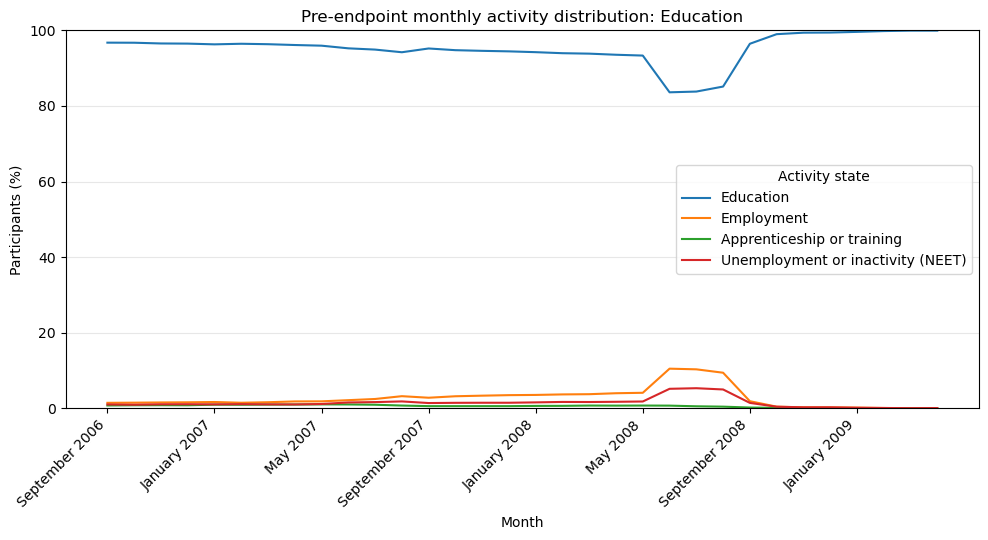

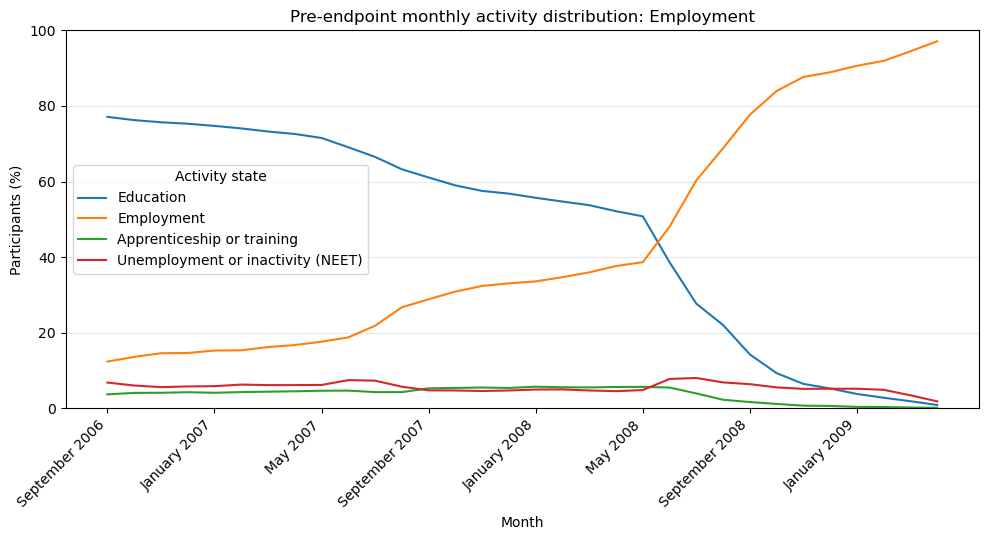

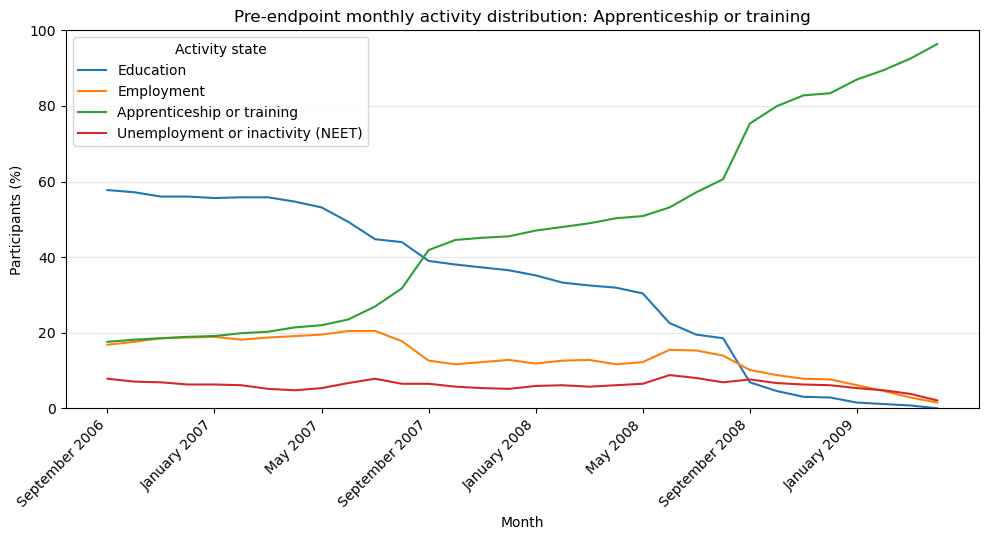

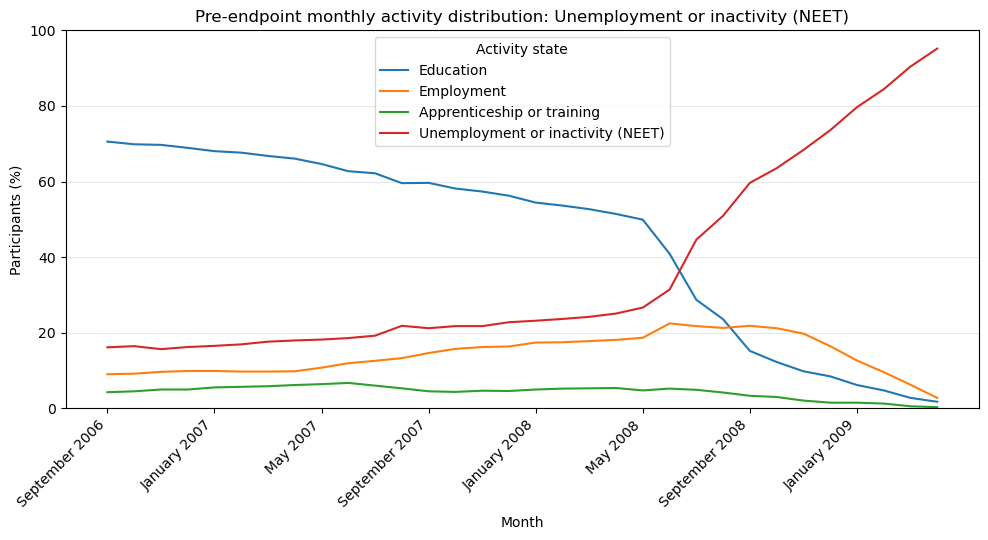

In [10]:
# 7: Plot monthly activity distributions by destination

for outcome in outcome_order:
    table = (
        monthly_by_destination.loc[monthly_by_destination["age18_outcome"].eq(outcome)]
        .pivot(index="month_number", columns="activity_state", values="Percentage")
        .reindex(columns=activity_order, fill_value=0)
    )

    ax = table.plot(figsize=(10, 5.5))
    ax.set_title(f"Pre-endpoint monthly activity distribution: {outcome}")
    ax.set_xlabel("Month")
    ax.set_ylabel("Participants (%)")
    ax.set_ylim(0, 100)
    ax.set_xticks(list(range(1, 33, 4)))
    ax.set_xticklabels([month_labels[position - 1] for position in range(1, 33, 4)], rotation=45, ha="right")
    ax.legend(title="Activity state")
    ax.grid(axis="y", alpha=0.3)
    figure = ax.get_figure()
    figure.tight_layout()
    file_name = outcome.lower().replace(" ", "_").replace("/", "_").replace("(", "").replace(")", "")
    figure.savefig(stage_7_dir / f"monthly_activity_distribution_{file_name}.png", dpi=300, bbox_inches="tight")
    plt.show()


In [11]:
# 8: Summarise continuity into the May 2009 destination

thresholds = [1, 3, 6, 12, 24, 32]
continuity_rows = []

for outcome in outcome_order:
    subset = history_characteristics.loc[history_characteristics["age18_outcome"].eq(outcome)]
    row = {"Age-18 destination": outcome, "Participants": len(subset)}
    for months in thresholds:
        row[f"At least {months} continuous months (%)"] = (
            subset["terminal_endpoint_spell_months"].ge(months).mean() * 100
        )
    continuity_rows.append(row)

continuity_summary = pd.DataFrame(continuity_rows)
continuity_summary.to_csv(
    stage_7_dir / "destination_continuity_before_may_2009.csv",
    index=False,
)

display(continuity_summary.round(2))


,Age-18 destination,Participants,At least 1 continuous months (%),At least 3 continuous months (%),At least 6 continuous months (%),At least 12 continuous months (%),At least 24 continuous months (%),At least 32 continuous months (%)
0,Education,5124,99.92,99.79,99.32,81.40,78.28,77.99
1,Employment,2813,97.12,91.75,86.21,33.81,10.84,6.79
2,Apprenticeship or training,523,96.37,89.48,82.79,46.65,17.02,13.96
3,Unemployment or inactivity (NEET),1264,95.17,84.34,66.93,18.20,7.52,5.78


### Participant-resampling stability check

Stage 1 assessed the stability of the six-cluster solution across repeated initialisations. This check instead resamples participants with replacement while retaining the fixed 32-month history definition and six-cluster specification.

For each resample, the fitted clusters are aligned to the fixed six-cluster assignment before adjusted Rand index and cluster-specific Jaccard similarity are calculated. These are descriptive sensitivity diagnostics and are not used to select a different number of clusters.


In [12]:
# 9: Prepare the Hamming-distance representation for resampling

from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import adjusted_rand_score

unique_histories, participant_history_index, history_frequencies = np.unique(
    history_values,
    axis=0,
    return_inverse=True,
    return_counts=True,
)

distance_matrix = squareform(
    pdist(unique_histories, metric="hamming")
).astype("float32") * 32

cluster_labels_full = (
    sequence_history[["NSID"]]
    .merge(
        sequence_clusters[["NSID", "sequence_cluster_id"]],
        on="NSID",
        how="left",
        validate="one_to_one",
    )["sequence_cluster_id"]
    .to_numpy(dtype=int)
)

if set(np.unique(cluster_labels_full)) != set(range(1, 7)):
    raise ValueError("The six cluster identifiers are not 1 to 6.")

print(f"Unique 32-month histories: {len(unique_histories):,}")
print(f"Distance matrix shape: {distance_matrix.shape}")


Unique 32-month histories: 2,090
Distance matrix shape: (2090, 2090)


In [13]:
# 10: Define weighted k-medoids for the resampling check

def fit_weighted_kmedoids(
    distance,
    weights,
    clusters,
    initialisations=3,
    max_iterations=100,
    random_state=2026,
):
    active = np.flatnonzero(weights > 0)
    active_distance = distance[np.ix_(active, active)].astype(np.float64)
    active_weights = weights[active].astype(np.float64)
    master_rng = np.random.default_rng(random_state)
    best = None

    for initialisation in range(initialisations):
        rng = np.random.default_rng(
            master_rng.integers(0, np.iinfo(np.int32).max)
        )
        first_medoid = rng.choice(
            len(active),
            p=active_weights / active_weights.sum(),
        )
        medoids = [int(first_medoid)]

        while len(medoids) < clusters:
            nearest_distance = active_distance[:, medoids].min(axis=1)
            selection_score = active_weights * nearest_distance ** 2

            if selection_score.sum() == 0:
                remaining = np.setdiff1d(
                    np.arange(len(active)),
                    np.array(medoids),
                )
                next_medoid = rng.choice(
                    remaining,
                    p=active_weights[remaining] / active_weights[remaining].sum(),
                )
            else:
                next_medoid = rng.choice(
                    len(active),
                    p=selection_score / selection_score.sum(),
                )

            medoids.append(int(next_medoid))

        medoids = np.array(medoids, dtype=int)

        for _ in range(max_iterations):
            labels = np.argmin(active_distance[:, medoids], axis=1)
            updated_medoids = np.empty(clusters, dtype=int)

            for cluster_number in range(clusters):
                members = np.flatnonzero(labels == cluster_number)
                if len(members) == 0:
                    raise RuntimeError("An empty cluster was produced.")

                within_cluster = active_distance[np.ix_(members, members)]
                candidate_costs = within_cluster @ active_weights[members]
                updated_medoids[cluster_number] = members[np.argmin(candidate_costs)]

            if np.array_equal(updated_medoids, medoids):
                break
            medoids = updated_medoids

        labels = np.argmin(active_distance[:, medoids], axis=1)
        assigned_distances = active_distance[
            np.arange(len(active)),
            medoids[labels],
        ]
        objective = np.sum(active_weights * assigned_distances)

        if best is None or objective < best["objective"]:
            best = {
                "medoids": active[medoids].copy(),
                "objective": float(objective),
                "initialisation": initialisation + 1,
            }

    return best


In [14]:
# 11: Run the participant-resampling stability check

RESAMPLING_REPETITIONS = 30
RESAMPLING_INITIALISATIONS = 3
RESAMPLING_RANDOM_STATE = 2026

rng = np.random.default_rng(RESAMPLING_RANDOM_STATE)
resampling_rows = []
cluster_similarity_rows = []

for repetition in range(1, RESAMPLING_REPETITIONS + 1):
    weights = rng.multinomial(
        len(history_values),
        history_frequencies / history_frequencies.sum(),
    )

    solution = fit_weighted_kmedoids(
        distance_matrix,
        weights,
        clusters=6,
        initialisations=RESAMPLING_INITIALISATIONS,
        random_state=RESAMPLING_RANDOM_STATE + repetition,
    )

    labels_unique = distance_matrix[:, solution["medoids"]].argmin(axis=1)
    labels_participant = labels_unique[participant_history_index]

    overlap = np.zeros((6, 6), dtype=int)
    for cluster_full in range(1, 7):
        for cluster_resampled in range(6):
            overlap[cluster_full - 1, cluster_resampled] = np.sum(
                (cluster_labels_full == cluster_full)
                & (labels_participant == cluster_resampled)
            )

    rows, cols = linear_sum_assignment(-overlap)
    mapping = {col: row + 1 for row, col in zip(rows, cols)}
    labels_aligned = np.array([mapping[label] for label in labels_participant], dtype=int)

    resampling_rows.append({
        "Repetition": repetition,
        "Weighted objective": solution["objective"],
        "Adjusted Rand index": adjusted_rand_score(cluster_labels_full, labels_aligned),
        "Unique histories represented": int((weights > 0).sum()),
    })

    for cluster_id in range(1, 7):
        full_members = cluster_labels_full == cluster_id
        resampled_members = labels_aligned == cluster_id
        union = np.sum(full_members | resampled_members)
        jaccard = np.sum(full_members & resampled_members) / union
        cluster_similarity_rows.append({
            "Repetition": repetition,
            "sequence_cluster_id": cluster_id,
            "Jaccard": jaccard,
        })

resampling_stability = pd.DataFrame(resampling_rows)
cluster_resampling_stability = pd.DataFrame(cluster_similarity_rows)

cluster_resampling_summary = (
    cluster_resampling_stability
    .groupby("sequence_cluster_id", as_index=False)
    .agg(
        Mean_Jaccard=("Jaccard", "mean"),
        Median_Jaccard=("Jaccard", "median"),
        Minimum_Jaccard=("Jaccard", "min"),
        Maximum_Jaccard=("Jaccard", "max"),
    )
    .merge(
        sequence_clusters[["sequence_cluster_id", "sequence_cluster"]].drop_duplicates(),
        on="sequence_cluster_id",
        validate="one_to_one",
    )
    .sort_values("sequence_cluster_id")
)

resampling_stability.to_csv(stage_7_dir / "sequence_cluster_resampling_stability.csv", index=False)
cluster_resampling_stability.to_csv(stage_7_dir / "sequence_cluster_resampling_jaccard.csv", index=False)
cluster_resampling_summary.to_csv(stage_7_dir / "sequence_cluster_resampling_summary.csv", index=False)

display(resampling_stability[["Adjusted Rand index", "Unique histories represented"]].describe().round(3))
display(cluster_resampling_summary.round(3))


,Adjusted Rand index,Unique histories represented
count,30.000,30.000
mean,0.875,1432.967
std,0.098,17.657
min,0.548,1385.000
25%,0.818,1428.000
50%,0.876,1436.000
75%,0.951,1444.000
max,0.997,1460.000


,sequence_cluster_id,Mean_Jaccard,Median_Jaccard,Minimum_Jaccard,Maximum_Jaccard,sequence_cluster
0,1,0.941,0.941,0.757,0.999,Predominantly education
1,2,0.831,0.833,0.122,0.998,Later transition to employment
2,3,0.533,0.544,0.009,1.000,Earlier transition to employment
3,4,0.594,0.678,0.004,0.995,Predominantly employed
4,5,0.836,0.876,0.281,0.991,Predominantly NEET
5,6,0.853,0.900,0.053,0.971,Predominantly apprenticeship/training


## Part 3: Sequence Clusters, Transitions and Age-18 Destinations

The six sequence clusters summarise broad pre-endpoint activity patterns. Their composition within the four May 2009 destinations and their transition frequencies are examined descriptively.


In [15]:
# 1: Link sequence clusters, destinations and direct history characteristics

cluster_data = (
    history_characteristics
    .merge(
        sequence_clusters,
        on="NSID",
        how="inner",
        validate="one_to_one",
    )
)

cluster_order_table = (
    sequence_clusters[["sequence_cluster_id", "sequence_cluster"]]
    .drop_duplicates()
    .sort_values("sequence_cluster_id")
)
cluster_order = cluster_order_table["sequence_cluster"].tolist()

cluster_outcome_counts = pd.crosstab(
    cluster_data["sequence_cluster"],
    cluster_data["age18_outcome"],
).reindex(index=cluster_order, columns=outcome_order, fill_value=0)

cluster_outcome_counts.to_csv(
    stage_7_dir / "sequence_cluster_by_age18_destination_counts.csv"
)

display(cluster_outcome_counts)


age18_outcome,Education,Employment,Apprenticeship or training,Unemployment or inactivity (NEET)
sequence_cluster,,,,
Predominantly education,4928,185,142,519
Later transition to employment,7,1404,39,154
Earlier transition to employment,121,632,33,114
Predominantly employed,30,460,29,87
Predominantly NEET,24,72,16,347
Predominantly apprenticeship/training,14,60,264,43


In [16]:
# 2: Calculate destination composition within clusters and cluster composition within destinations

destinations_within_clusters = (
    cluster_outcome_counts
    .div(cluster_outcome_counts.sum(axis=1), axis=0)
    .mul(100)
)
clusters_within_destinations = (
    cluster_outcome_counts
    .div(cluster_outcome_counts.sum(axis=0), axis=1)
    .mul(100)
)

destinations_within_clusters.to_csv(
    stage_7_dir / "age18_destination_composition_within_sequence_clusters.csv"
)
clusters_within_destinations.to_csv(
    stage_7_dir / "sequence_cluster_composition_within_age18_destinations.csv"
)

print("Age-18 destinations within each sequence cluster (%)")
display(destinations_within_clusters.round(2))
print("Sequence clusters within each age-18 destination (%)")
display(clusters_within_destinations.round(2))


Age-18 destinations within each sequence cluster (%)


age18_outcome,Education,Employment,Apprenticeship or training,Unemployment or inactivity (NEET)
sequence_cluster,,,,
Predominantly education,85.35,3.20,2.46,8.99
Later transition to employment,0.44,87.53,2.43,9.60
Earlier transition to employment,13.44,70.22,3.67,12.67
Predominantly employed,4.95,75.91,4.79,14.36
Predominantly NEET,5.23,15.69,3.49,75.60
Predominantly apprenticeship/training,3.67,15.75,69.29,11.29


Sequence clusters within each age-18 destination (%)


age18_outcome,Education,Employment,Apprenticeship or training,Unemployment or inactivity (NEET)
sequence_cluster,,,,
Predominantly education,96.17,6.58,27.15,41.06
Later transition to employment,0.14,49.91,7.46,12.18
Earlier transition to employment,2.36,22.47,6.31,9.02
Predominantly employed,0.59,16.35,5.54,6.88
Predominantly NEET,0.47,2.56,3.06,27.45
Predominantly apprenticeship/training,0.27,2.13,50.48,3.40


In [17]:
# 3: Summarise transition frequency by sequence cluster

cluster_transition_summary = (
    cluster_data
    .groupby(
        ["sequence_cluster_id", "sequence_cluster"],
        observed=True,
    )
    .agg(
        Participants=("NSID", "size"),
        Mean_transitions=("transition_count", "mean"),
        Median_transitions=("transition_count", "median"),
        Maximum_transitions=("transition_count", "max"),
        Mean_distinct_states=("distinct_state_count", "mean"),
        Median_months_in_destination_state=("months_in_endpoint_state", "median"),
    )
    .reset_index()
    .sort_values("sequence_cluster_id")
)

transition_order = ["0", "1", "2", "3+"]

cluster_transition_counts = (
    pd.crosstab(
        cluster_data["sequence_cluster"],
        cluster_data["transition_band"],
        dropna=False,
    )
    .reindex(
        index=cluster_order,
        columns=transition_order,
        fill_value=0,
    )
)

cluster_transition_distribution = (
    cluster_transition_counts
    .rename_axis(
        index="sequence_cluster",
        columns="transition_band",
    )
    .stack()
    .rename("Participants")
    .reset_index()
    .merge(
        cluster_order_table,
        on="sequence_cluster",
        how="left",
        validate="many_to_one",
    )
)

cluster_transition_distribution["Percentage within cluster"] = (
    cluster_transition_distribution["Participants"]
    / cluster_transition_distribution.groupby(
        "sequence_cluster_id"
    )["Participants"].transform("sum")
    * 100
)

cluster_transition_distribution = (
    cluster_transition_distribution[
        [
            "sequence_cluster_id",
            "sequence_cluster",
            "transition_band",
            "Participants",
            "Percentage within cluster",
        ]
    ]
    .sort_values(
        ["sequence_cluster_id", "transition_band"]
    )
    .reset_index(drop=True)
)

if len(cluster_transition_distribution) != 24:
    raise ValueError("Expected six clusters across four transition bands.")

if cluster_transition_distribution["Participants"].sum() != len(cluster_data):
    raise ValueError("Transition-band counts do not reproduce the sequence sample.")

cluster_transition_summary.to_csv(
    stage_7_dir / "history_characteristics_by_sequence_cluster.csv",
    index=False,
)
cluster_transition_distribution.to_csv(
    stage_7_dir / "transition_count_distribution_by_sequence_cluster.csv",
    index=False,
)

display(cluster_transition_summary.round(2))
display(cluster_transition_distribution.round(2))

,sequence_cluster_id,sequence_cluster,Participants,Mean_transitions,Median_transitions,Maximum_transitions,Mean_distinct_states,Median_months_in_destination_state
0,1,Predominantly education,5774,0.55,0.0,7,1.35,32.0
1,2,Later transition to employment,1604,1.59,1.0,6,2.32,9.0
2,3,Earlier transition to employment,900,1.99,2.0,7,2.45,19.0
3,4,Predominantly employed,606,1.49,1.0,7,1.89,27.0
4,5,Predominantly NEET,459,2.22,2.0,8,2.27,20.0
5,6,Predominantly apprenticeship/training,381,1.66,1.0,7,2.22,20.0


,sequence_cluster_id,sequence_cluster,transition_band,Participants,Percentage within cluster
0,1,Predominantly education,0,4024,69.69
1,1,Predominantly education,1,626,10.84
2,1,Predominantly education,2,887,15.36
3,1,Predominantly education,3+,237,4.10
4,2,Later transition to employment,0,0,0.00
5,2,Later transition to employment,1,1027,64.03
6,2,Later transition to employment,2,299,18.64
7,2,Later transition to employment,3+,278,17.33
8,3,Earlier transition to employment,0,0,0.00
9,3,Earlier transition to employment,1,393,43.67


In [18]:
# 4: Quantify the cluster-destination association

from scipy.stats import chi2_contingency

observed = cluster_outcome_counts.to_numpy()
chi2, p_value, degrees_freedom, expected = chi2_contingency(observed)
n = observed.sum()
rows, columns = observed.shape
phi_squared = chi2 / n
phi_squared_corrected = max(
    0,
    phi_squared - ((rows - 1) * (columns - 1) / (n - 1)),
)
rows_corrected = rows - ((rows - 1) ** 2 / (n - 1))
columns_corrected = columns - ((columns - 1) ** 2 / (n - 1))
cramers_v_corrected = np.sqrt(
    phi_squared_corrected / min(rows_corrected - 1, columns_corrected - 1)
)

association_summary = pd.DataFrame({
    "Participants": [n],
    "Chi-square": [chi2],
    "Degrees of freedom": [degrees_freedom],
    "P-value": [p_value],
    "Bias-corrected Cramer's V": [cramers_v_corrected],
    "Minimum expected count": [expected.min()],
    "Expected counts below 5": [int((expected < 5).sum())],
})

association_summary.to_csv(
    stage_7_dir / "sequence_cluster_age18_destination_association.csv",
    index=False,
)

display(association_summary.round(3))


,Participants,Chi-square,Degrees of freedom,P-value,Bias-corrected Cramer's V,Minimum expected count,Expected counts below 5
0,9724,11654.101,15,0.0,0.632,20.492,0


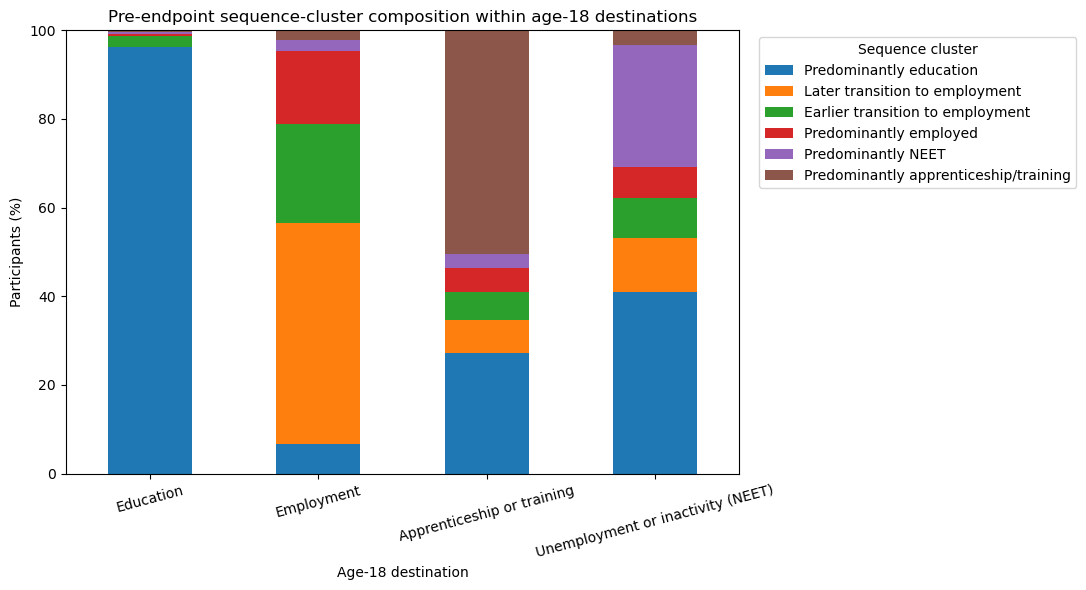

In [19]:
# 5: Plot cluster composition within each destination

ax = clusters_within_destinations.T.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
)
ax.set_xlabel("Age-18 destination")
ax.set_ylabel("Participants (%)")
ax.set_title("Pre-endpoint sequence-cluster composition within age-18 destinations")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=15)
ax.legend(title="Sequence cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
figure = ax.get_figure()
figure.tight_layout()
figure.savefig(
    stage_7_dir / "sequence_cluster_composition_within_age18_destinations.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## Part 4: Longitudinal Heterogeneity Within Age-18 Destinations

Direct history measures and sequence-cluster composition are summarised within each age-18 destination.


In [20]:
# 1: Summarise longitudinal heterogeneity within each destination

heterogeneity_rows = []
for outcome in outcome_order:
    composition = clusters_within_destinations[outcome].sort_values(ascending=False)
    direct = history_characteristics.loc[history_characteristics["age18_outcome"].eq(outcome)]
    heterogeneity_rows.append({
        "Age-18 destination": outcome,
        "Participants": len(direct),
        "Mean months in destination state": direct["months_in_endpoint_state"].mean(),
        "Median months in destination state": direct["months_in_endpoint_state"].median(),
        "Mean transitions": direct["transition_count"].mean(),
        "Median transitions": direct["transition_count"].median(),
        "Three or more transitions (%)": direct["transition_count"].ge(3).mean() * 100,
        "Mean distinct states": direct["distinct_state_count"].mean(),
        "Median terminal spell (months)": direct["terminal_endpoint_spell_months"].median(),
        "Destination state absent before May (%)": direct["months_in_endpoint_state"].eq(0).mean() * 100,
        "Largest sequence cluster": composition.index[0],
        "Largest sequence cluster (%)": composition.iloc[0],
        "Second-largest sequence cluster": composition.index[1],
        "Second-largest sequence cluster (%)": composition.iloc[1],
        "Clusters representing at least 5%": int(composition.ge(5).sum()),
    })

endpoint_longitudinal_summary = pd.DataFrame(heterogeneity_rows)
endpoint_longitudinal_summary.to_csv(
    stage_7_dir / "age18_destination_longitudinal_summary.csv",
    index=False,
)

display(endpoint_longitudinal_summary.round(2))


,Age-18 destination,Participants,Mean months in destination state,Median months in destination state,Mean transitions,Median transitions,Three or more transitions (%),Mean distinct states,Median terminal spell (months),Destination state absent before May (%),Largest sequence cluster,Largest sequence cluster (%),Second-largest sequence cluster,Second-largest sequence cluster (%),Clusters representing at least 5%
0,Education,5124,30.46,32.0,0.46,0.0,2.36,1.25,32.0,0.00,Predominantly education,96.17,Earlier transition to employment,2.36,1
1,Employment,2813,13.99,11.0,1.55,1.0,19.37,2.19,10.0,1.35,Later transition to employment,49.91,Earlier transition to employment,22.47,4
2,Apprenticeship or training,523,15.38,14.0,1.73,2.0,22.75,2.36,10.0,2.68,Predominantly apprenticeship/training,50.48,Predominantly education,27.15,5
3,Unemployment or inactivity (NEET),1264,11.63,9.0,1.97,2.0,30.78,2.38,8.0,3.64,Predominantly education,41.06,Predominantly NEET,27.45,5


## Part 5: Class-Specific Performance in Longitudinal Context

Held-out class performance is placed beside the longitudinal descriptors for the same four destinations. Sequence information is not used by the classifiers.


In [21]:
# 1: Load Stage 6 class-specific performance

stage_6_audit = pd.read_csv(paths["Stage 6 audit"])
stage_6_class = pd.read_csv(paths["Stage 6 class performance"])

stage_6_audit_passed = (
    stage_6_audit["Passed"]
    .astype("string")
    .str.strip()
    .str.lower()
    .eq("true")
    .all()
)
if not stage_6_audit_passed:
    raise AssertionError("Stage 6 audit contains a failed check.")

model_order = ["MLR", "RF", "XGBoost", "BRF"]
class_performance = stage_6_class.loc[
    stage_6_class["Model"].isin(model_order)
].copy()

expected_models = set(model_order)
if set(class_performance["Model"]) != expected_models:
    raise ValueError("Stage 6 class performance does not contain the four model families.")
if not class_performance.groupby("Model")["Outcome"].nunique().eq(4).all():
    raise ValueError("A Stage 6 model does not contain all four destination rows.")

display(class_performance.round(4))


,Model,Internal class,Outcome code,Outcome,Precision,Recall,F1,Support
4,MLR,0,1,Education,0.7400,0.6720,0.7044,991
5,MLR,1,4,Employment,0.4399,0.2875,0.3477,560
6,MLR,2,5,Apprenticeship or training,0.1384,0.4231,0.2085,104
7,MLR,3,6,Unemployment or inactivity (NEET),0.2679,0.3440,0.3012,250
8,RF,0,1,Education,0.7185,0.7780,0.7471,991
9,RF,1,4,Employment,0.4772,0.4857,0.4814,560
10,RF,2,5,Apprenticeship or training,0.2667,0.1538,0.1951,104
11,RF,3,6,Unemployment or inactivity (NEET),0.3663,0.2960,0.3274,250
12,XGBoost,0,1,Education,0.7381,0.7023,0.7198,991
13,XGBoost,1,4,Employment,0.4444,0.4857,0.4642,560


In [22]:
# 2: Combine class performance with longitudinal characteristics

support_table = (
    class_performance[["Outcome", "Support"]]
    .drop_duplicates()
    .rename(columns={"Outcome": "Age-18 destination", "Support": "Held-out support"})
)

recall_table = (
    class_performance
    .pivot(index="Outcome", columns="Model", values="Recall")
    .rename(columns={model: f"{model} recall" for model in model_order})
    .rename_axis(None, axis=1)
    .reset_index()
    .rename(columns={"Outcome": "Age-18 destination"})
)

f1_table = (
    class_performance
    .pivot(index="Outcome", columns="Model", values="F1")
    .rename(columns={model: f"{model} F1" for model in model_order})
    .rename_axis(None, axis=1)
    .reset_index()
    .rename(columns={"Outcome": "Age-18 destination"})
)

performance_longitudinal_context = (
    endpoint_longitudinal_summary
    .merge(support_table, on="Age-18 destination", validate="one_to_one")
    .merge(recall_table, on="Age-18 destination", validate="one_to_one")
    .merge(f1_table, on="Age-18 destination", validate="one_to_one")
)

performance_longitudinal_context.to_csv(
    stage_7_dir / "longitudinal_characteristics_and_class_performance.csv",
    index=False,
)

display(performance_longitudinal_context.round(3))


,Age-18 destination,Participants,Mean months in destination state,Median months in destination state,Mean transitions,Median transitions,Three or more transitions (%),Mean distinct states,Median terminal spell (months),Destination state absent before May (%),...,Clusters representing at least 5%,Held-out support,BRF recall,MLR recall,RF recall,XGBoost recall,BRF F1,MLR F1,RF F1,XGBoost F1
0,Education,5124,30.458,32.0,0.458,0.0,2.361,1.246,32.0,0.000,...,1,991,0.720,0.672,0.778,0.702,0.725,0.704,0.747,0.720
1,Employment,2813,13.991,11.0,1.550,1.0,19.374,2.186,10.0,1.351,...,4,560,0.402,0.288,0.486,0.486,0.422,0.348,0.481,0.464
2,Apprenticeship or training,523,15.380,14.0,1.734,2.0,22.753,2.361,10.0,2.677,...,5,104,0.260,0.423,0.154,0.192,0.235,0.209,0.195,0.211
3,Unemployment or inactivity (NEET),1264,11.634,9.0,1.965,2.0,30.775,2.377,8.0,3.639,...,5,250,0.372,0.344,0.296,0.276,0.342,0.301,0.327,0.268


## Part 6: Pre-Endpoint Histories by Classification Status

Correctly and incorrectly classified held-out cases are compared within each observed destination using duration, transitions, number of observed states and terminal continuity.


In [23]:
# 1: Load and align participant-level held-out predictions

stage_6_predictions = pd.read_csv(
    paths["Stage 6 predictions"],
    dtype={"NSID": "string"},
)
stage_6_predictions["NSID"] = stage_6_predictions["NSID"].str.strip()

prediction_data = stage_6_predictions.loc[
    stage_6_predictions["Model"].isin(model_order)
].copy()

if not prediction_data.groupby("Model")["NSID"].nunique().eq(1905).all():
    raise ValueError("Each model must contain 1,905 unique held-out identifiers.")

prediction_data = prediction_data.merge(
    cluster_data[
        [
            "NSID",
            "age18_outcome",
            "sequence_cluster_id",
            "sequence_cluster",
            "months_in_endpoint_state",
            "transition_count",
            "transition_band",
            "distinct_state_count",
            "terminal_endpoint_spell_months",
        ]
    ],
    on="NSID",
    how="left",
    validate="many_to_one",
    indicator=True,
)

linked_predictions = prediction_data.loc[prediction_data["_merge"].eq("both")].copy()
unlinked_predictions = prediction_data.loc[prediction_data["_merge"].eq("left_only")].copy()

if linked_predictions["Actual outcome"].ne(linked_predictions["age18_outcome"]).any():
    raise ValueError("Stage 6 outcomes do not align with the sequence data.")

prediction_alignment = pd.DataFrame({
    "Measure": [
        "Held-out participants per model",
        "Sequence-linked held-out participants per model",
        "Held-out participants without complete sequences per model",
    ],
    "Participants": [
        prediction_data.groupby("Model")["NSID"].nunique().min(),
        linked_predictions.groupby("Model")["NSID"].nunique().min(),
        (
            prediction_data.groupby("Model")["NSID"].nunique().min()
            - linked_predictions.groupby("Model")["NSID"].nunique().min()
        ),
    ],
})

display(prediction_alignment)


,Measure,Participants
0,Held-out participants per model,1905
1,Sequence-linked held-out participants per model,1893
2,Held-out participants without complete sequenc...,12


In [24]:
# 2: Mark correct and incorrect classifications

linked_predictions["Correctly classified"] = (
    linked_predictions["Actual outcome"]
    .eq(linked_predictions["Predicted outcome"])
)


In [25]:
# 3: Compare direct history characteristics by classification status

linked_predictions["Classification status"] = np.where(
    linked_predictions["Correctly classified"],
    "Correctly classified",
    "Incorrectly classified",
)

classification_history_summary = (
    linked_predictions
    .groupby(["Actual outcome", "Model", "Classification status"], observed=True)
    .agg(
        Participants=("NSID", "size"),
        Mean_months_in_destination_state=("months_in_endpoint_state", "mean"),
        Median_months_in_destination_state=("months_in_endpoint_state", "median"),
        Mean_transitions=("transition_count", "mean"),
        Median_transitions=("transition_count", "median"),
        Three_or_more_transitions_percentage=("transition_count", lambda values: values.ge(3).mean() * 100),
        Mean_distinct_states=("distinct_state_count", "mean"),
        Median_terminal_spell_months=("terminal_endpoint_spell_months", "median"),
    )
    .reset_index()
)

transition_status_distribution = (
    linked_predictions
    .groupby(
        ["Actual outcome", "Model", "Classification status", "transition_band"],
        observed=False,
    )
    .size()
    .reset_index(name="Participants")
)
transition_status_distribution["Percentage within classification status"] = (
    transition_status_distribution["Participants"]
    / transition_status_distribution.groupby(
        ["Actual outcome", "Model", "Classification status"]
    )["Participants"].transform("sum")
    * 100
)

classification_history_summary.to_csv(
    stage_7_dir / "held_out_history_characteristics_by_classification_status.csv",
    index=False,
)
transition_status_distribution.to_csv(
    stage_7_dir / "held_out_transition_distribution_by_classification_status.csv",
    index=False,
)

display(classification_history_summary.round(2))
display(transition_status_distribution.round(2))


,Actual outcome,Model,Classification status,Participants,Mean_months_in_destination_state,Median_months_in_destination_state,Mean_transitions,Median_transitions,Three_or_more_transitions_percentage,Mean_distinct_states,Median_terminal_spell_months
0,Apprenticeship or training,BRF,Correctly classified,27,21.37,21.0,1.33,1.0,14.81,2.11,21.0
1,Apprenticeship or training,BRF,Incorrectly classified,77,12.42,10.0,1.95,2.0,23.38,2.62,8.0
2,Apprenticeship or training,MLR,Correctly classified,44,19.20,20.0,1.73,1.0,27.27,2.30,20.0
3,Apprenticeship or training,MLR,Incorrectly classified,60,11.47,8.0,1.83,2.0,16.67,2.63,8.0
4,Apprenticeship or training,RF,Correctly classified,16,24.12,23.0,1.19,1.0,12.50,2.00,23.0
5,Apprenticeship or training,RF,Incorrectly classified,88,13.03,10.0,1.90,2.0,22.73,2.58,9.0
6,Apprenticeship or training,XGBoost,Correctly classified,20,24.05,23.0,1.10,1.0,10.00,1.95,23.0
7,Apprenticeship or training,XGBoost,Incorrectly classified,84,12.52,10.0,1.95,2.0,23.81,2.62,9.0
8,Education,BRF,Correctly classified,714,31.03,32.0,0.40,0.0,0.98,1.21,32.0
9,Education,BRF,Incorrectly classified,276,29.09,32.0,0.66,0.0,4.71,1.37,32.0


,Actual outcome,Model,Classification status,transition_band,Participants,Percentage within classification status
0,Apprenticeship or training,BRF,Correctly classified,0,8,29.63
1,Apprenticeship or training,BRF,Correctly classified,1,10,37.04
2,Apprenticeship or training,BRF,Correctly classified,2,5,18.52
3,Apprenticeship or training,BRF,Correctly classified,3+,4,14.81
4,Apprenticeship or training,BRF,Incorrectly classified,0,5,6.49
...,...,...,...,...,...,...
123,Unemployment or inactivity (NEET),XGBoost,Correctly classified,3+,27,40.30
124,Unemployment or inactivity (NEET),XGBoost,Incorrectly classified,0,10,5.62
125,Unemployment or inactivity (NEET),XGBoost,Incorrectly classified,1,73,41.01
126,Unemployment or inactivity (NEET),XGBoost,Incorrectly classified,2,48,26.97


In [26]:
# 4: Calculate differences between correct and incorrect classifications

correct = (
    classification_history_summary.loc[
        classification_history_summary["Classification status"].eq("Correctly classified")
    ]
    .set_index(["Actual outcome", "Model"])
)
incorrect = (
    classification_history_summary.loc[
        classification_history_summary["Classification status"].eq("Incorrectly classified")
    ]
    .set_index(["Actual outcome", "Model"])
)

history_difference_summary = pd.DataFrame({
    "Correctly classified": correct["Participants"],
    "Incorrectly classified": incorrect["Participants"],
    "Difference in mean destination-state months": (
        correct["Mean_months_in_destination_state"] - incorrect["Mean_months_in_destination_state"]
    ),
    "Difference in mean transitions": correct["Mean_transitions"] - incorrect["Mean_transitions"],
    "Difference in median transitions": correct["Median_transitions"] - incorrect["Median_transitions"],
    "Difference in 3+ transitions (percentage points)": (
        correct["Three_or_more_transitions_percentage"]
        - incorrect["Three_or_more_transitions_percentage"]
    ),
    "Difference in mean distinct states": correct["Mean_distinct_states"] - incorrect["Mean_distinct_states"],
    "Difference in median terminal spell": (
        correct["Median_terminal_spell_months"] - incorrect["Median_terminal_spell_months"]
    ),
}).reset_index()

history_difference_summary.to_csv(
    stage_7_dir / "held_out_history_differences_by_classification_status.csv",
    index=False,
)

display(history_difference_summary.round(2))


,Actual outcome,Model,Correctly classified,Incorrectly classified,Difference in mean destination-state months,Difference in mean transitions,Difference in median transitions,Difference in 3+ transitions (percentage points),Difference in mean distinct states,Difference in median terminal spell
0,Apprenticeship or training,BRF,27,77,8.95,-0.61,-1.0,-8.56,-0.51,13.0
1,Apprenticeship or training,MLR,44,60,7.74,-0.11,-1.0,10.61,-0.34,12.0
2,Apprenticeship or training,RF,16,88,11.09,-0.71,-1.0,-10.23,-0.58,14.0
3,Apprenticeship or training,XGBoost,20,84,11.53,-0.85,-1.0,-13.81,-0.67,14.0
4,Education,BRF,714,276,1.93,-0.25,0.0,-3.73,-0.16,0.0
5,Education,MLR,666,324,1.64,-0.29,0.0,-3.88,-0.17,0.0
6,Education,RF,771,219,2.50,-0.40,0.0,-5.03,-0.24,0.0
7,Education,XGBoost,696,294,1.89,-0.28,0.0,-2.93,-0.17,0.0
8,Employment,BRF,225,329,1.45,-0.06,0.0,-5.79,0.04,0.0
9,Employment,MLR,161,393,0.93,0.03,0.0,0.99,0.00,0.0


In [27]:
# 5: Compare Stage 6 recall with the sequence-linked test subset

sequence_linked_recall = (
    linked_predictions
    .groupby(["Model", "Actual outcome"], observed=True)
    .agg(
        Sequence_linked_support=("NSID", "size"),
        Sequence_linked_recall=("Correctly classified", "mean"),
    )
    .reset_index()
    .rename(columns={"Actual outcome": "Outcome"})
)

full_test_recall = class_performance[["Model", "Outcome", "Support", "Recall"]].rename(
    columns={"Support": "Full_test_support", "Recall": "Full_test_recall"}
)

sequence_subset_check = full_test_recall.merge(
    sequence_linked_recall,
    on=["Model", "Outcome"],
    validate="one_to_one",
)
sequence_subset_check["Support difference"] = (
    sequence_subset_check["Sequence_linked_support"] - sequence_subset_check["Full_test_support"]
)
sequence_subset_check["Recall difference (percentage points)"] = (
    sequence_subset_check["Sequence_linked_recall"] - sequence_subset_check["Full_test_recall"]
) * 100

sequence_subset_check.to_csv(
    stage_7_dir / "held_out_sequence_subset_performance_check.csv",
    index=False,
)

display(sequence_subset_check.round(4))


,Model,Outcome,Full_test_support,Full_test_recall,Sequence_linked_support,Sequence_linked_recall,Support difference,Recall difference (percentage points)
0,MLR,Education,991,0.6720,990,0.6727,-1,0.0679
1,MLR,Employment,560,0.2875,554,0.2906,-6,0.3114
2,MLR,Apprenticeship or training,104,0.4231,104,0.4231,0,0.0000
3,MLR,Unemployment or inactivity (NEET),250,0.3440,245,0.3347,-5,-0.9306
4,RF,Education,991,0.7780,990,0.7788,-1,0.0786
5,RF,Employment,560,0.4857,554,0.4874,-6,0.1650
6,RF,Apprenticeship or training,104,0.1538,104,0.1538,0,0.0000
7,RF,Unemployment or inactivity (NEET),250,0.2960,245,0.2939,-5,-0.2122
8,XGBoost,Education,991,0.7023,990,0.7030,-1,0.0709
9,XGBoost,Employment,560,0.4857,554,0.4874,-6,0.1650


## Part 7: Interpretation

Stage 7 describes pre-endpoint activity histories for the fixed May 2009 destination. Differences in duration, continuity, transition timing and sequence composition provide longitudinal context for the held-out classification results.

## Part 8: Final Audit


In [28]:
# 1: Run the Stage 7 audit

required_outputs = [
    "individual_pre_endpoint_history_characteristics.csv",
    "history_characteristics_by_age18_destination.csv",
    "transition_count_distribution_by_age18_destination.csv",
    "monthly_activity_distribution_by_age18_destination.csv",
    "destination_continuity_before_may_2009.csv",
    "sequence_cluster_resampling_stability.csv",
    "sequence_cluster_resampling_jaccard.csv",
    "sequence_cluster_resampling_summary.csv",
    "sequence_cluster_by_age18_destination_counts.csv",
    "sequence_cluster_composition_within_age18_destinations.csv",
    "history_characteristics_by_sequence_cluster.csv",
    "transition_count_distribution_by_sequence_cluster.csv",
    "sequence_cluster_age18_destination_association.csv",
    "age18_destination_longitudinal_summary.csv",
    "longitudinal_characteristics_and_class_performance.csv",
    "held_out_history_characteristics_by_classification_status.csv",
    "held_out_transition_distribution_by_classification_status.csv",
    "held_out_history_differences_by_classification_status.csv",
    "held_out_sequence_subset_performance_check.csv",
]

stage_7_audit = pd.DataFrame([
    {
        "Check": "Complete sequence identifiers are unique",
        "Passed": sequence_history["NSID"].is_unique,
    },
    {
        "Check": "Sequence-cluster identifiers are unique",
        "Passed": sequence_clusters["NSID"].is_unique,
    },
    {
        "Check": "Sequence and cluster identifiers match",
        "Passed": set(sequence_history["NSID"]) == set(sequence_clusters["NSID"]),
    },
    {
        "Check": "Thirty-two pre-endpoint months are present",
        "Passed": len(history_columns) == 32,
    },
    {
        "Check": "May 2009 is excluded from the history",
        "Passed": endpoint_variable not in history_columns,
    },
    {
        "Check": "Six sequence clusters are present",
        "Passed": sequence_clusters["sequence_cluster_id"].nunique() == 6,
    },
    {
        "Check": "Thirty participant-resampling repetitions completed",
        "Passed": (
            resampling_stability["Repetition"].nunique()
            == RESAMPLING_REPETITIONS
        ),
    },
    {
        "Check": "Resampling diagnostics contain all six clusters",
        "Passed": cluster_resampling_summary["sequence_cluster_id"].nunique() == 6,
    },
    {
        "Check": "Stage 6 audit passed",
        "Passed": stage_6_audit_passed,
    },
    {
        "Check": "Each Stage 6 model has 1,905 held-out participants",
        "Passed": (
            prediction_data.groupby("Model")["NSID"]
            .nunique()
            .eq(1_905)
            .all()
        ),
    },
    {
        "Check": "Linked Stage 6 outcomes match Stage 7 outcomes",
        "Passed": (
            linked_predictions["Actual outcome"]
            .eq(linked_predictions["age18_outcome"])
            .all()
        ),
    },
    {
        "Check": "Core Stage 7 output files are present",
        "Passed": all(
            (stage_7_dir / name).is_file()
            for name in required_outputs
        ),
    },
])

sample_summary = pd.DataFrame({
    "Analysis sample": [
        "Age-18 outcome sample",
        "Complete pre-endpoint sequence sample",
        "Modelling sample",
        "Sequence-modelling overlap",
        "Held-out test sample",
        "Sequence-linked held-out test sample",
    ],
    "Participants": [
        len(outcome_data),
        len(sequence_history),
        len(modelling_data),
        len(sequence_modelling),
        prediction_data.groupby("Model")["NSID"].nunique().min(),
        linked_predictions.groupby("Model")["NSID"].nunique().min(),
    ],
})

stage_7_audit.to_csv(
    stage_7_dir / "stage_7_final_audit.csv",
    index=False,
)
sample_summary.to_csv(
    stage_7_dir / "stage_7_analysis_sample_summary.csv",
    index=False,
)

display(stage_7_audit)
display(sample_summary)

if not stage_7_audit["Passed"].all():
    failed = stage_7_audit.loc[
        ~stage_7_audit["Passed"],
        "Check",
    ].tolist()
    raise AssertionError(
        "Stage 7 audit failed: " + "; ".join(failed)
    )

print("Stage 7 audit passed.")


,Check,Passed
0,Complete sequence identifiers are unique,True
1,Sequence-cluster identifiers are unique,True
2,Sequence and cluster identifiers match,True
3,Thirty-two pre-endpoint months are present,True
4,May 2009 is excluded from the history,True
5,Six sequence clusters are present,True
6,Thirty participant-resampling repetitions comp...,True
7,Resampling diagnostics contain all six clusters,True
8,Stage 6 audit passed,True
9,"Each Stage 6 model has 1,905 held-out particip...",True


,Analysis sample,Participants
0,Age-18 outcome sample,9767
1,Complete pre-endpoint sequence sample,9724
2,Modelling sample,9524
3,Sequence-modelling overlap,9481
4,Held-out test sample,1905
5,Sequence-linked held-out test sample,1893


Stage 7 audit passed.


## Stage 7 Summary

Complete 32-month pre-endpoint histories were available for 9,724 participants. The six descriptive sequence clusters were associated with the May 2009 destination, but correspondence was not one-to-one.

Participant-resampling sensitivity across 30 repetitions produced a mean adjusted Rand index of 0.875 and cluster-specific mean Jaccard similarities from 0.533 to 0.941.

Education was predominantly preceded by continuous education, while Employment, Apprenticeship or training, and NEET contained more varied preceding histories and transition patterns.

The sequence analysis linked to 1,893 of 1,905 held-out test participants. Within the same observed destination, correctly and incorrectly classified cases differed in preceding duration and continuity. Correctly classified Apprenticeship or training cases spent 7.74–11.53 more months in that state on average, depending on the model; the corresponding difference for NEET was 6.80–7.88 months.

These activity histories provide descriptive longitudinal context only. They were not predictors and do not establish causes of classification errors.
